# Assignment 1: Profiling Codes
Group 15
- NG, Cheuk Nam (cnng@kth.se)
- WONG, Chun Him (chwon@kth.se)

#### Imports

In [31]:
import time
from timeit import default_timer as timer
from functools import wraps
import numpy as np
import psutil

# Exercise I: Profiling the Julia Set Code

## Task 1.1 Calculate the Clock Granularity of different Python Timers

1) ### With `time.time()`

In [32]:
def checktick():
    M = 200
    timesfound = np.empty((M,))
    for i in range(M):
        t1 = time.time() # get timestamp from timer
        t2 = time.time() # get timestamp from timer
        while (t2 - t1) < 1e-16: # if zero then we are below clock granularity, retake timing
            t2 = time.time() # get timestamp from timer
        t1 = t2 # this is outside the loop
        timesfound[i] = t1 # record the time stamp
    minDelta = 1000000
    Delta = np.diff(timesfound) # it should be cast to int only when needed
    minDelta = Delta.min()
    return minDelta
print("time.time() clock granularity: %e s" % checktick())

time.time() clock granularity: 7.152557e-07 s


2) ### With `timeit`

In [33]:
def checktick():
    M = 200
    timesfound = np.empty((M,))
    for i in range(M):
        t1 = timer() # get timestamp from timer
        t2 = timer() # get timestamp from timer
        while (t2 - t1) < 1e-16: # if zero then we are below clock granularity, retake timing
            t2 = timer() # get timestamp from timer
        t1 = t2 # this is outside the loop
        timesfound[i] = t1 # record the time stamp
    minDelta = 1000000
    Delta = np.diff(timesfound) # it should be cast to int only when needed
    minDelta = Delta.min()
    return minDelta
print("timeit clock granularity: %e s" % checktick())

timeit clock granularity: 1.249718e-07 s


3) ### With `time.time_ns()`

In [34]:
def checktick():
    M = 200
    timesfound = np.empty((M,))
    for i in range(M):
        t1 = time.time_ns() # get timestamp from timer
        t2 = time.time_ns() # get timestamp from timer
        while (t2 - t1) < 1e-16: # if zero then we are below clock granularity, retake timing
            t2 = time.time_ns() # get timestamp from timer
        t1 = t2 # this is outside the loop
        timesfound[i] = t1 # record the time stamp
    minDelta = 1000000
    Delta = np.diff(timesfound) # it should be cast to int only when needed
    minDelta = Delta.min()
    return minDelta
print("time.time() clock granularity: %e ns" % checktick())

time.time() clock granularity: 7.680000e+02 ns


## Task 1.2 Timing the Julia set code functions

`Timeit` has the best clock granularity among the three timers tested above. Therefore, I use `timeit` to time the Julia set code functions.

In [35]:
"""Julia set generator without optional PIL-based image drawing"""
# area of complex space to investigate
x1, x2, y1, y2 = -1.8, 1.8, -1.8, 1.8
c_real, c_imag = -0.62772, -.42193

# decorator to time
def timefn(fn):
    @wraps(fn)
    def measure_time(*args, **kwargs):
        t1 = timer()
        result = fn(*args, **kwargs)
        t2 = timer()
        print(f"@timefn: {fn.__name__} took {t2 - t1} seconds")
        return result
    return measure_time

@timefn
def calc_pure_python(desired_width, max_iterations):
    """Create a list of complex coordinates (zs) and complex parameters (cs),
    build Julia set"""
    x_step = (x2 - x1) / desired_width
    y_step = (y1 - y2) / desired_width
    x = []
    y = []
    ycoord = y2
    while ycoord > y1:
        y.append(ycoord)
        ycoord += y_step
    xcoord = x1
    while xcoord < x2:
        x.append(xcoord)
        xcoord += x_step
    # build a list of coordinates and the initial condition for each cell.
    # Note that our initial condition is a constant and could easily be removed,
    # we use it to simulate a real-world scenario with several inputs to our
    # function
    zs = []
    cs = []
    for ycoord in y:
        for xcoord in x:
            zs.append(complex(xcoord, ycoord))
            cs.append(complex(c_real, c_imag))

    print("Length of x:", len(x))
    print("Total elements:", len(zs))
    start_time = time.time()
    output = calculate_z_serial_purepython(max_iterations, zs, cs)
    end_time = time.time()
    secs = end_time - start_time
    # print(calculate_z_serial_purepython.__name__ + " took", secs, "seconds")

    # This sum is expected for a 1000^2 grid with 300 iterations
    # It ensures that our code evolves exactly as we'd intended
    assert sum(output) == 33219980

@timefn
def calculate_z_serial_purepython(maxiter, zs, cs):
    """Calculate output list using Julia update rule"""
    output = [0] * len(zs)
    for i in range(len(zs)):
        n = 0
        z = zs[i]
        c = cs[i]
        while abs(z) < 2 and n < maxiter:
            z = z * z + c
            n += 1
        output[i] = n
    return output

if __name__ == "__main__":
    # Calculate the Julia set using a pure Python solution with
    # reasonable defaults for a laptop
    calc_pure_python(desired_width=1000, max_iterations=300)

Length of x: 1000
Total elements: 1000000
@timefn: calculate_z_serial_purepython took 1.8548854169785045 seconds
@timefn: calc_pure_python took 1.9846684589865617 seconds


The above code was run 10 times and the average time and their corresponding standard deviations are as follows:

| Run                    | calc_pure_python (s) | calculate_z_serial_purepython (s) |
|------------------------|----------------------|-----------------------------------|
| 1                      | 1.6460210420191288   | 1.5471606670180336                |
| 2                      | 1.829247374960687    | 1.7324306250084192                |
| 3                      | 1.6537152499658987   | 1.5582562089548446                |
| 4                      | 1.9431911670253612   | 1.846423249982763                 |
| 5                      | 1.8339538750005886   | 1.5811095830285922                |
| 6                      | 1.644327334011905    | 1.5485797080327757                |
| 7                      | 1.664894582994748    | 1.5704846250009723                |
| 8                      | 1.64977145800367     | 1.5531713340315036                |
| 9                      | 1.6521273750113323   | 1.5556108329910785                |
| 10                     | 1.6534901250270195   | 1.5559448749991134                |
| Average Time (s)       | 	1.717073958402      | 1.6049171709048                   |
| Standard Deviation (s) | 0.10355721746071     | 0.096193175360614                 |

When comparing the standard deviations of the two functions with the clock granularity of `timeit`, it is obvious that they are significantly larger than the clock granularity. This indicates that the timing measurements are not significantly affected by the limitations of the timer's resolution.

## Task 1.3 Profile the Julia set code with cProfile and line_profiler the computation

### With cProfile
```bash
python -m cProfile -s cumulative JuliaSet.py
```
   ncalls | tottime | percall | cumtime | percall | filename:lineno(function)
   ------ | ------- | ------- | ------- | ------- | -------------------------
   1 |   0.219 |   0.219 |   4.187 |   4.187 | JuliaSet.py:24(calc_pure_python)
   1 |   2.645 |   2.645 |   3.892 |   3.892 | JuliaSet.py:63(calculate_z_serial_purepython)

### With line_profiler
```bash
python -m kernprof -l JuliaSet.py
```
`Timer unit: 1e-06 s`
#### Function: calc_pure_python at line 23
```
Total time: 26.904 s
Line #      Hits         Time  Per Hit   % Time  Line Contents
==============================================================
    23                                           @profile
    24                                           def calc_pure_python(desired_width, max_iterations):
    25                                               """Create a list of complex coordinates (zs) and complex parameters (cs),
    26                                               build Julia set"""
    27         1          1.0      1.0      0.0      x_step = (x2 - x1) / desired_width
    28         1          1.0      1.0      0.0      y_step = (y1 - y2) / desired_width
    29         1          0.0      0.0      0.0      x = []
    30         1          1.0      1.0      0.0      y = []
    31         1          0.0      0.0      0.0      ycoord = y2
    32      1001        148.0      0.1      0.0      while ycoord > y1:
    33      1000        154.0      0.2      0.0          y.append(ycoord)
    34      1000        135.0      0.1      0.0          ycoord += y_step
    35         1          0.0      0.0      0.0      xcoord = x1
    36      1001        166.0      0.2      0.0      while xcoord < x2:
    37      1000        136.0      0.1      0.0          x.append(xcoord)
    38      1000        132.0      0.1      0.0          xcoord += x_step
    39                                               # build a list of coordinates and the initial condition for each cell.
    40                                               # Note that our initial condition is a constant and could easily be removed,
    41                                               # we use it to simulate a real-world scenario with several inputs to our
    42                                               # function
    43         1          0.0      0.0      0.0      zs = []
    44         1          0.0      0.0      0.0      cs = []
    45      1001        175.0      0.2      0.0      for ycoord in y:
    46   1001000     151641.0      0.2      0.6          for xcoord in x:
    47   1000000     178805.0      0.2      0.7              zs.append(complex(xcoord, ycoord))
    48   1000000     187474.0      0.2      0.7              cs.append(complex(c_real, c_imag))
    49
    50         1         21.0     21.0      0.0      print("Length of x:", len(x))
    51         1          3.0      3.0      0.0      print("Total elements:", len(zs))
    52         1          1.0      1.0      0.0      start_time = time.time()
    53         1   26382746.0 2.64e+07     98.1      output = calculate_z_serial_purepython(max_iterations, zs, cs)
    54         1          4.0      4.0      0.0      end_time = time.time()
    55         1          3.0      3.0      0.0      secs = end_time - start_time
    56         1         31.0     31.0      0.0      print(calculate_z_serial_purepython.__name__ + " took", secs, "seconds")
    57
    58                                               # This sum is expected for a 1000^2 grid with 300 iterations
    59                                               # It ensures that our code evolves exactly as we'd intended
    60         1       2212.0   2212.0      0.0      assert sum(output) == 33219980
```
#### Function: calculate_z_serial_purepython at line 62
```
Total time: 18.855 s

Line #      Hits         Time  Per Hit   % Time  Line Contents
==============================================================
    62                                           @profile
    63                                           def calculate_z_serial_purepython(maxiter, zs, cs):
    64                                               """Calculate output list using Julia update rule"""
    65         1        472.0    472.0      0.0      output = [0] * len(zs)
    66   1000001     176330.0      0.2      0.9      for i in range(len(zs)):
    67   1000000     163153.0      0.2      0.9          n = 0
    68   1000000     175652.0      0.2      0.9          z = zs[i]
    69   1000000     165613.0      0.2      0.9          c = cs[i]
    70  34219980    6494024.0      0.2     34.4          while abs(z) < 2 and n < maxiter:
    71  33219980    6118674.0      0.2     32.5              z = z * z + c
    72  33219980    5394531.0      0.2     28.6              n += 1
    73   1000000     166519.0      0.2      0.9          output[i] = n
    74         1          2.0      2.0      0.0      return output
```

### Snakeviz Visualization
```bash
python -m snakeviz profile.stats --server
```
![snakeviz](julia_profile.png)

### Overhead Analysis
To measure the overhead introduced by cProfile and line_profiler, the code is timed with the unix `time` command in three different scenarios: without any profiling (no @profile), with cProfile (no @profile), and with line_profiler (with decorators). Given the significant performance penalty associated with profiling, a coarse-grained timer serves as an appropriate tool for basic timing.

| Scenario                                                          | Real Time (s) |
|-------------------------------------------------------------------|---------------|
| Without Profiling `time python JuliaSet.py`                       | 1.692         |
| With cProfile `time python -m cProfile -s cumulative JuliaSet.py` | 4.272         |
| With line_profiler `time python -m kernprof -l JuliaSet.py`       | 29.361        |

## Task 1.4 Memory-profile the JuliaSet code

```bash
python -m memory_profiler JuliaSet.py
```

> To reduce running time, the above memory profiling was done with 10 iterations instead of 300.

#### Function: calc_pure_python at line 23
```
Line #    Mem usage    Increment  Occurrences   Line Contents
=============================================================
    23   82.859 MiB   82.859 MiB           1   @profile
    24                                         def calc_pure_python(desired_width, max_iterations):
    25                                             """Create a list of complex coordinates (zs) and complex parameters (cs),
    26                                             build Julia set"""
    27   82.859 MiB    0.000 MiB           1       x_step = (x2 - x1) / desired_width
    28   82.859 MiB    0.000 MiB           1       y_step = (y1 - y2) / desired_width
    29   82.859 MiB    0.000 MiB           1       x = []
    30   82.859 MiB    0.000 MiB           1       y = []
    31   82.859 MiB    0.000 MiB           1       ycoord = y2
    32   82.906 MiB    0.031 MiB        1001       while ycoord > y1:
    33   82.906 MiB    0.016 MiB        1000           y.append(ycoord)
    34   82.906 MiB    0.000 MiB        1000           ycoord += y_step
    35   82.906 MiB    0.000 MiB           1       xcoord = x1
    36   82.938 MiB    0.031 MiB        1001       while xcoord < x2:
    37   82.938 MiB    0.000 MiB        1000           x.append(xcoord)
    38   82.938 MiB    0.000 MiB        1000           xcoord += x_step
    39                                             # build a list of coordinates and the initial condition for each cell.
    40                                             # Note that our initial condition is a constant and could easily be removed,
    41                                             # we use it to simulate a real-world scenario with several inputs to our
    42                                             # function
    43   82.938 MiB    0.000 MiB           1       zs = []
    44   82.938 MiB    0.000 MiB           1       cs = []
    45  166.688 MiB    0.000 MiB        1001       for ycoord in y:
    46  166.688 MiB    0.000 MiB     1001000           for xcoord in x:
    47  166.688 MiB   72.625 MiB     1000000               zs.append(complex(xcoord, ycoord))
    48  166.688 MiB   11.125 MiB     1000000               cs.append(complex(c_real, c_imag))
    49
    50  166.688 MiB    0.000 MiB           1       print("Length of x:", len(x))
    51  166.688 MiB    0.000 MiB           1       print("Total elements:", len(zs))
    52  166.688 MiB    0.000 MiB           1       start_time = time.time()
    53  188.656 MiB  188.656 MiB           1       output = calculate_z_serial_purepython(max_iterations, zs, cs)
    54  188.656 MiB    0.000 MiB           1       end_time = time.time()
    55  188.656 MiB    0.000 MiB           1       secs = end_time - start_time
    56  188.656 MiB    0.000 MiB           1       print(calculate_z_serial_purepython.__name__ + " took", secs, "seconds")
    57
    58                                             # This sum is expected for a 1000^2 grid with 300 iterations
    59                                             # It ensures that our code evolves exactly as we'd intended
    60                                             # assert sum(output) == 33219980
```
### Function: calculate_z_serial_purepython at line 62
```
Line #    Mem usage    Increment  Occurrences   Line Contents
=============================================================
    62  166.688 MiB  166.688 MiB           1   @profile
    63                                         def calculate_z_serial_purepython(maxiter, zs, cs):
    64                                             """Calculate output list using Julia update rule"""
    65  174.344 MiB    7.656 MiB           1       output = [0] * len(zs)
    66  188.656 MiB    0.000 MiB     1000001       for i in range(len(zs)):
    67  188.656 MiB    0.000 MiB     1000000           n = 0
    68  188.656 MiB    7.156 MiB     1000000           z = zs[i]
    69  188.656 MiB    7.156 MiB     1000000           c = cs[i]
    70  188.656 MiB    0.000 MiB     3988736           while abs(z) < 2 and n < maxiter:
    71  188.656 MiB    0.000 MiB     2988736               z = z * z + c
    72  188.656 MiB    0.000 MiB     2988736               n += 1
    73  188.656 MiB    0.000 MiB     1000000           output[i] = n
    74  188.656 MiB    0.000 MiB           1       return output
```

> The following memory statistics were collected with the original 300 iterations.

### Collecting Memory Statistics
```bash
python -m mprof run JuliaSet.py
```

### Visualising Memory Usage with mprof
```bash
python -m mprof plot julia_mprofile.dat
```
![mprof](julia_mprof.png)

### Overhead Analysis
To measure the overhead introduced by cProfile and line_profiler, the code is timed with the unix `time` command in three different scenarios: without any profiling (no @profile), with memory_profiler (with @profile), and with mprof (with @profile). Given the significant performance penalty associated with profiling, a coarse-grained timer serves as an appropriate tool for basic timing. **All are done with 10 iterations instead of 300 to reduce running time.**

| Scenario                                                          | Real Time (s) |
|-------------------------------------------------------------------|---------------|
| Without Profiling `time python JuliaSet.py`                       | 0.308         |
| With memory_profiler `time python -m memory_profiler JuliaSet.py` | 3:32.69       |
| With mprof `time python -m mprof run JuliaSet.py`                 | 0.715         |

# Exercise II: Profiling Diffusion Process Code

The file `Diffusion.py` contains the following code for profiling with the experiment being run for 300 iterations.

In [39]:
grid_shape = (640, 640)

def evolve(grid, dt, D=1.0):
    xmax, ymax = grid_shape
    new_grid = [[0.0] * ymax for x in range(xmax)]
    for i in range(xmax):
        for j in range(ymax):
            grid_xx = (
                    grid[(i + 1) % xmax][j] + grid[(i - 1) % xmax][j] - 2.0 * grid[i][j]
            )
            grid_yy = (
                    grid[i][(j + 1) % ymax] + grid[i][(j - 1) % ymax] - 2.0 * grid[i][j]
            )
            new_grid[i][j] = grid[i][j] + D * (grid_xx + grid_yy) * dt
    return new_grid

def run_experiment(num_iterations):
    # Setting up initial conditions
    xmax, ymax = grid_shape
    grid = [[0.0] * ymax for x in range(xmax)]

    # These initial conditions are simulating a drop of dye in the middle of our
    # simulated region
    block_low = int(grid_shape[0] * 0.4)
    block_high = int(grid_shape[0] * 0.5)
    for i in range(block_low, block_high):
        for j in range(block_low, block_high):
            grid[i][j] = 0.005

    # Evolve the initial conditions
    for i in range(num_iterations):
        grid = evolve(grid, 0.1)

if __name__ == "__main__":
    run_experiment(300)

## Task 2.1 Profile the diffusion code with cProfile and line_profiler the computation

### With cProfile
```bash
python -m cProfile -s cumulative Diffusion.py
```

```
304 function calls in 18.929 seconds

ncalls  tottime  percall  cumtime  percall filename:lineno(function)
    1    0.000    0.000   18.929   18.929 {built-in method builtins.exec}
    1    0.002    0.002   18.929   18.929 Diffusion.py:1(<module>)
    1    0.467    0.467   18.927   18.927 Diffusion.py:17(run_experiment)
  300   18.459    0.062   18.459    0.062 Diffusion.py:3(evolve)
    1    0.000    0.000    0.000    0.000 {method 'disable' of '_lsprof.Profiler' objects}
```

### With line_profiler
```bash
python -m kernprof -l Diffusion.py
```

```
Timer unit: 1e-06 s

Total time: 140.727 s
File: Diffusion.py
Function: evolve at line 3

Line #      Hits         Time  Per Hit   % Time  Line Contents
==============================================================
     3                                           @profile
     4                                           def evolve(grid, dt, D=1.0):
     5       300        294.0      1.0      0.0      xmax, ymax = grid_shape
     6       300      37253.0    124.2      0.0      new_grid = [[0.0] * ymax for x in range(xmax)]
     7    192300      33973.0      0.2      0.0      for i in range(xmax):
     8 123072000   21260026.0      0.2     15.1          for j in range(ymax):
     9 122880000   20142275.0      0.2     14.3              grid_xx = (
    10 122880000   27531128.0      0.2     19.6                      grid[(i + 1) % xmax][j] + grid[(i - 1) % xmax][j] - 2.0 * grid[i][j]
    11                                                       )
    12 122880000   20100690.0      0.2     14.3              grid_yy = (
    13 122880000   27626248.0      0.2     19.6                      grid[i][(j + 1) % ymax] + grid[i][(j - 1) % ymax] - 2.0 * grid[i][j]
    14                                                       )
    15 122880000   23994958.0      0.2     17.1              new_grid[i][j] = grid[i][j] + D * (grid_xx + grid_yy) * dt
    16       300        521.0      1.7      0.0      return new_grid
```

### Snakeviz Visualization
```bash
python -m snakeviz diffusion_profile.stats --server
```
![snakeviz](diffusion_profile.png)

## Task 2.2 Memory-profile the diffusion code

```bash
python -m memory_profiler Diffusion.py
```

> To reduce running time, the above memory profiling was done with 5 iterations instead of 300 for the `evolve` function.

```
Line #    Mem usage    Increment  Occurrences   Line Contents
=============================================================
     3   92.359 MiB   42.969 MiB           5   @profile
     4                                         def evolve(grid, dt, D=1.0):
     5   92.359 MiB    0.000 MiB           5       xmax, ymax = grid_shape
     6   92.359 MiB    3.297 MiB        3205       new_grid = [[0.0] * ymax for x in range(xmax)]
     7  102.359 MiB -11521.172 MiB        3205       for i in range(xmax):
     8  102.359 MiB -7394948.047 MiB     2051200           for j in range(ymax):
     9  102.359 MiB -7383370.781 MiB     2048000               grid_xx = (
    10  102.359 MiB -7383426.875 MiB     2048000                       grid[(i + 1) % xmax][j] + grid[(i - 1) % xmax][j] - 2.0 * grid[i][j]
    11                                                     )
    12  102.359 MiB -7383395.875 MiB     2048000               grid_yy = (
    13  102.359 MiB -7383395.875 MiB     2048000                       grid[i][(j + 1) % ymax] + grid[i][(j - 1) % ymax] - 2.0 * grid[i][j]
    14                                                     )
    15  102.359 MiB -7383395.875 MiB     2048000               new_grid[i][j] = grid[i][j] + D * (grid_xx + grid_yy) * dt
    16  102.359 MiB    0.000 MiB           5       return new_grid

```

> The following memory statistics were collected with the original 300 iterations.

### Collecting Memory Statistics
```bash
python -m mprof run Diffusion.py
```

### Visualising Memory Usage with mprof
```bash
python -m mprof plot diffusion_mprofile.dat
```
![mprof](diffusion_mprof.png)

## Bonus Exercise: Develop your profiler tool for monitoring CPU percentage use with psutil

In [ ]:
import time
import threading
import matplotlib.pyplot as plt

# Sample CPU usage while the function runs, then show ONE final plot + table.

class CpuProfiler:
    def __init__(self, interval=1.0):
        self.interval = interval
        self.timestamps = []
        self.samples = []
        self._stop = threading.Event()
        self._thread = None
# Set up a function that runs in a background thread and collects CPU usage data and timestamps
    def _collect(self):
        start = time.time()
        while not self._stop.is_set():
            values = psutil.cpu_percent(interval=self.interval, percpu=True)
            self.timestamps.append(time.time() - start)
            self.samples.append(values)
#Initialization
    def start(self):
        self.timestamps = []
        self.samples = []
        self._stop.clear()
        psutil.cpu_percent(interval=1, percpu=True)  # prime psutil
        self._thread = threading.Thread(target=self._collect, daemon=True)
        self._thread.start()
#Stop the background thread
    def stop(self):
        self._stop.set()
        if self._thread is not None:
            self._thread.join()
#Plot the final CPU usage using matplotlib
    def plot_final(self, title="CPU Usage per Core"):
        if not self.samples:
            print("No samples collected.")
            return
        plt.figure(figsize=(10, 4))
        num_cores = len(self.samples[0])
        for core_idx in range(num_cores):
            y = [s[core_idx] for s in self.samples]
            plt.plot(self.timestamps, y, label=f"core {core_idx}")
        plt.xlabel("Time (s)")
        plt.ylabel("CPU usage (%)")
        plt.title(title)
        plt.legend(ncol=2, fontsize=8)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
#Print the CPU usage in a table format
    def table(self):
        if not self.samples:
            print("No samples collected.")
            return
        headers = ["time(s)"] + [f"Core {i}" for i in range(len(self.samples[0]))]
        print("| " + " | ".join(headers) + " |")
        print("| " + " | ".join(["---"] * len(headers)) + " |")
        for t, row in zip(self.timestamps, self.samples):
            values = [f"{t:.1f}"] + [f"{v:.1f}" for v in row]
            print("| " + " | ".join(values) + " |")

#A decorator to profile the CPU usage of a function
def cpu_profile(interval=1.0, post_seconds=0.0):
    def decorator(func):
        def wrapper(*args, **kwargs):
            profiler = CpuProfiler(interval=interval)
            profiler.start()
            try:
                result = func(*args, **kwargs)
            finally:
                if post_seconds > 0:
                    time.sleep(post_seconds)
                profiler.stop()
            profiler.plot_final(title=f"CPU Usage for {func.__name__}")
            profiler.table()
            return result
        return wrapper
    return decorator

Profiling Julia... (this may take a while)
Length of x: 1000
Total elements: 1000000
@timefn: calculate_z_serial_purepython took 1.8221291250083596 seconds
@timefn: calc_pure_python took 1.9617605420062318 seconds


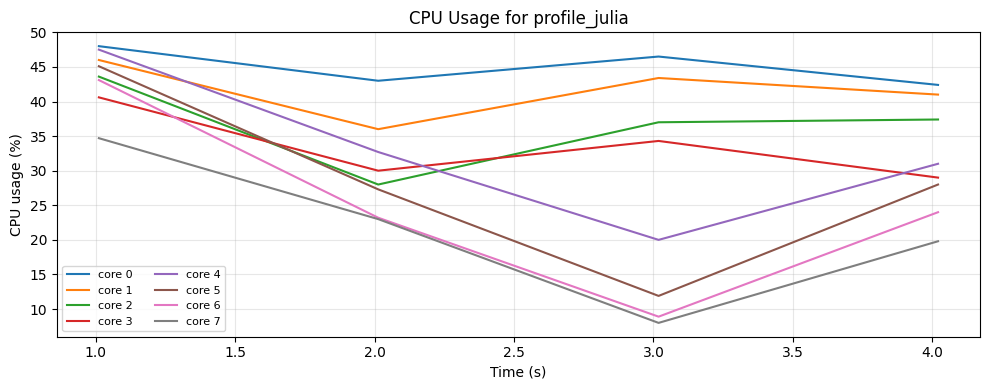

| time(s) | Core 0 | Core 1 | Core 2 | Core 3 | Core 4 | Core 5 | Core 6 | Core 7 |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 1.0 | 48.0 | 46.0 | 43.6 | 40.6 | 47.5 | 45.1 | 43.1 | 34.7 |
| 2.0 | 43.0 | 36.0 | 28.0 | 30.0 | 32.7 | 27.3 | 23.2 | 23.0 |
| 3.0 | 46.5 | 43.4 | 37.0 | 34.3 | 20.0 | 11.9 | 8.9 | 8.0 |
| 4.0 | 42.4 | 41.0 | 37.4 | 29.0 | 31.0 | 28.0 | 24.0 | 19.8 |
Profiling diffusion... (this may take a while)


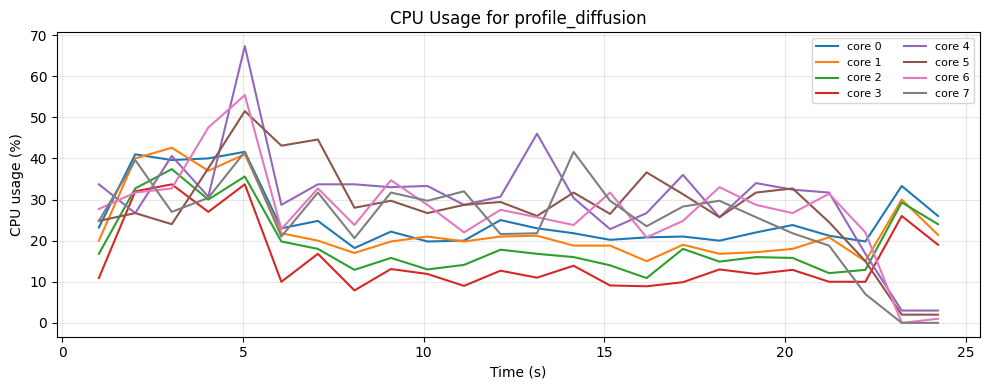

| time(s) | Core 0 | Core 1 | Core 2 | Core 3 | Core 4 | Core 5 | Core 6 | Core 7 |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 1.0 | 23.2 | 20.0 | 16.8 | 10.9 | 33.7 | 24.8 | 27.7 | 24.8 |
| 2.0 | 41.0 | 40.0 | 32.7 | 32.0 | 26.7 | 26.7 | 31.7 | 39.6 |
| 3.0 | 39.6 | 42.6 | 37.4 | 33.7 | 40.6 | 24.0 | 32.7 | 27.0 |
| 4.0 | 40.0 | 37.0 | 30.0 | 27.0 | 30.7 | 37.6 | 47.5 | 30.4 |
| 5.0 | 41.6 | 41.0 | 35.6 | 33.7 | 67.3 | 51.5 | 55.4 | 41.6 |
| 6.1 | 23.0 | 21.8 | 19.8 | 10.0 | 28.7 | 43.1 | 22.8 | 21.0 |
| 7.1 | 24.8 | 20.0 | 18.0 | 16.8 | 33.7 | 44.6 | 32.7 | 31.7 |
| 8.1 | 18.2 | 17.0 | 12.9 | 7.9 | 33.7 | 28.0 | 23.8 | 20.6 |
| 9.1 | 22.2 | 19.8 | 15.8 | 13.1 | 33.0 | 29.7 | 34.7 | 31.7 |
| 10.1 | 19.8 | 21.0 | 13.0 | 11.9 | 33.3 | 26.7 | 28.7 | 29.7 |
| 11.1 | 20.0 | 19.8 | 14.1 | 9.0 | 28.7 | 28.7 | 22.0 | 32.0 |
| 12.1 | 25.0 | 21.0 | 17.8 | 12.7 | 30.7 | 29.4 | 27.5 | 21.6 |
| 13.1 | 23.0 | 21.2 | 16.8 | 11.0 | 46.0 | 26.0 | 25.7 | 21.8 |
| 14.1 | 21.8 | 18.8 | 16.

In [51]:
julia_width = 1000
julia_iters = 300
diffusion_iters = 300  

@cpu_profile(interval=1.0, post_seconds=2)
def profile_julia():
    return calc_pure_python(desired_width=julia_width, max_iterations=julia_iters)

@cpu_profile(interval=1.0, post_seconds=2)
def profile_diffusion():
    return run_experiment(diffusion_iters)

print("Profiling Julia... (this may take a while)")
profile_julia()

print("Profiling diffusion... (this may take a while)")
profile_diffusion()
